In [2]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00


In [1]:
# ============================================
# 1. Monter Google Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install ultralytics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.6 MB/s eta 0:00:00


In [4]:

import os
import pickle
import numpy as np
from ultralytics import YOLO

# ============================================
# 2. Chemins adaptés à VOTRE structure
# ============================================
BASE     = '/content/drive/MyDrive/CV_dataset'
train_file = os.path.join(BASE, 'train', 'train')   # fichier pickle
test_file  = os.path.join(BASE, 'test',  'test')    # fichier pickle
meta_file  = os.path.join(BASE, 'meta')             # fichier pickle

# Vérification
for path in [train_file, test_file, meta_file]:
    print(f"{'✅' if os.path.isfile(path) else '❌'} {path}")

# ============================================
# 3. Charger les données
# ============================================
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='bytes')

train_data = load_pickle(train_file)
test_data  = load_pickle(test_file)
meta_data  = load_pickle(meta_file)

# ============================================
# 4. Extraire X, y et noms des classes
# ============================================
X_train = train_data[b'data']
y_train = np.array(train_data[b'fine_labels'])

X_test  = test_data[b'data']
y_test  = np.array(test_data[b'fine_labels'])

class_names = [c.decode('utf-8') for c in meta_data[b'fine_label_names']]

print(f"\n✅ Classes disponibles ({len(class_names)}) :")
for i, name in enumerate(class_names):
    print(f"  {i:3d} : {name}")

# ============================================
# 5. Preprocessing : reshape + normalisation
# ============================================
def preprocess(X):
    X = X.reshape(-1, 3, 32, 32)
    X = np.transpose(X, (0, 2, 3, 1))
    return X.astype('float32')   # garder [0,255] pour EfficientNet

X_train = preprocess(X_train)
X_test  = preprocess(X_test)

print(f"\nX_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape} — classes 0 à {y_train.max()}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ /content/drive/MyDrive/CV_dataset/train/train
✅ /content/drive/MyDrive/CV_dataset/test/test
✅ /content/drive/MyDrive/CV_dataset/meta

✅ Classes disponibles (100) :
    0 : apple
    1 : aquarium_fish
    2 : baby
    3 : bear
    4 : beaver
    5 : bed
    6 : bee
    7 : beetle
    8 : bicycle
    9 : bottle
   10 : bowl
   11 : boy
   12 : bridge
   13 : bus
   14 : butterfly
   15 : camel
   16 : can
   17 : castle
   18 : caterpillar
   19 : cattle
   20 : chair
   21 : chimpanzee
   22 : clock
   23 : cloud
   24 : cockroach
   25 : couch
   26 : crab
   27 : crocodile
   28 : cup
   29 : dinosaur
   30 : dolphin
   31 : elephant
   32 : flatfish
   33 : forest
   34 : fox


In [5]:
import cv2
from pathlib import Path
from tqdm import tqdm
from tensorflow.keras.utils import to_categorical

# ============================================
# 6. Choisir vos classes (ex: 20 classes)
# ============================================
CLASSES_CHOISIES = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                    10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

# Afficher les noms des classes choisies
print("Classes sélectionnées :")
for new_id, old_id in enumerate(CLASSES_CHOISIES):
    print(f"  {new_id} → {class_names[old_id]}")

# Filtrer et remapper les labels
label_map = {old: new for new, old in enumerate(CLASSES_CHOISIES)}

mask_train = np.isin(y_train, CLASSES_CHOISIES)
mask_test  = np.isin(y_test,  CLASSES_CHOISIES)

X_tr = X_train[mask_train]
y_tr = np.array([label_map[y] for y in y_train[mask_train]])

X_te = X_test[mask_test]
y_te = np.array([label_map[y] for y in y_test[mask_test]])

print(f"\nTrain filtré : {X_tr.shape[0]} images")
print(f"Test  filtré : {X_te.shape[0]} images")

# ============================================
# 7. Créer la structure de dossiers YOLO
# ============================================
YOLO_ROOT = '/content/drive/MyDrive/CV_dataset_yolo'

for split in ['train', 'val']:
    Path(f"{YOLO_ROOT}/images/{split}").mkdir(parents=True, exist_ok=True)
    Path(f"{YOLO_ROOT}/labels/{split}").mkdir(parents=True, exist_ok=True)

print("✅ Dossiers YOLO créés :")
print(f"  {YOLO_ROOT}/images/train/")
print(f"  {YOLO_ROOT}/images/val/")
print(f"  {YOLO_ROOT}/labels/train/")
print(f"  {YOLO_ROOT}/labels/val/")

# ============================================
# 8. Convertir et sauvegarder les images + labels
# ============================================
def save_yolo_dataset(X, y, split):
    img_dir   = f"{YOLO_ROOT}/images/{split}"
    label_dir = f"{YOLO_ROOT}/labels/{split}"

    for i, (img, label) in enumerate(tqdm(zip(X, y), total=len(X), desc=split)):
        # Sauvegarder image redimensionnée 64x64 (meilleure qualité que 32x32)
        img_resized = cv2.resize(
            img.astype(np.uint8),
            (64, 64),
            interpolation=cv2.INTER_CUBIC
        )
        img_bgr = cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR)
        cv2.imwrite(f"{img_dir}/{split}_{i:05d}.jpg", img_bgr)

        # Annotation YOLO : objet centré, bbox = image entière
        # format : class_id  x_center  y_center  width  height  (normalisé 0-1)
        with open(f"{label_dir}/{split}_{i:05d}.txt", 'w') as f:
            f.write(f"{label} 0.5 0.5 1.0 1.0\n")

    print(f"✅ {split} : {len(X)} images sauvegardées")

save_yolo_dataset(X_tr, y_tr, 'train')
save_yolo_dataset(X_te, y_te, 'val')

# ============================================
# 9. Créer le fichier dataset.yaml
# ============================================
selected_names = [class_names[i] for i in CLASSES_CHOISIES]
names_yaml = '\n'.join([f"  {i}: {name}" for i, name in enumerate(selected_names)])

yaml_content = f"""path: {YOLO_ROOT}
train: images/train
val: images/val

nc: {len(CLASSES_CHOISIES)}

names:
{names_yaml}
"""

yaml_path = f"{YOLO_ROOT}/dataset.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"\n✅ dataset.yaml créé :\n{yaml_content}")

# ============================================
# 10. Entraînement YOLO
# ============================================
from ultralytics import YOLO

model = YOLO('yolov8n.pt')   # nano = rapide sur Colab gratuit

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=64,            # adapté à vos images 64x64
    batch=64,
    patience=10,
    save=True,
    project='/content/drive/MyDrive/yolo_results',
    name='cifar100_yolo',
    device=0
)

# ============================================
# 11. Évaluation
# ============================================
best = YOLO('/content/drive/MyDrive/yolo_results/cifar100_yolo/weights/best.pt')
metrics = best.val()

print(f"\n✅ Résultats YOLO :")
print(f"  mAP@50    : {metrics.box.map50:.3f}")
print(f"  mAP@50-95 : {metrics.box.map:.3f}")
print(f"  Précision : {metrics.box.p.mean():.3f}")
print(f"  Rappel    : {metrics.box.r.mean():.3f}")



Classes sélectionnées :
  0 → apple
  1 → aquarium_fish
  2 → baby
  3 → bear
  4 → beaver
  5 → bed
  6 → bee
  7 → beetle
  8 → bicycle
  9 → bottle
  10 → bowl
  11 → boy
  12 → bridge
  13 → bus
  14 → butterfly
  15 → camel
  16 → can
  17 → castle
  18 → caterpillar
  19 → cattle

Train filtré : 10000 images
Test  filtré : 2000 images
✅ Dossiers YOLO créés :
  /content/drive/MyDrive/CV_dataset_yolo/images/train/
  /content/drive/MyDrive/CV_dataset_yolo/images/val/
  /content/drive/MyDrive/CV_dataset_yolo/labels/train/
  /content/drive/MyDrive/CV_dataset_yolo/labels/val/


train: 100%|██████████| 10000/10000 [43:42<00:00,  3.81it/s]


✅ train : 10000 images sauvegardées


val: 100%|██████████| 2000/2000 [00:44<00:00, 44.69it/s]


✅ val : 2000 images sauvegardées

✅ dataset.yaml créé :
path: /content/drive/MyDrive/CV_dataset_yolo
train: images/train
val: images/val

nc: 20

names:
  0: apple
  1: aquarium_fish
  2: baby
  3: bear
  4: beaver
  5: bed
  6: bee
  7: beetle
  8: bicycle
  9: bottle
  10: bowl
  11: boy
  12: bridge
  13: bus
  14: butterfly
  15: camel
  16: can
  17: castle
  18: caterpillar
  19: cattle

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CV_dataset_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, fl

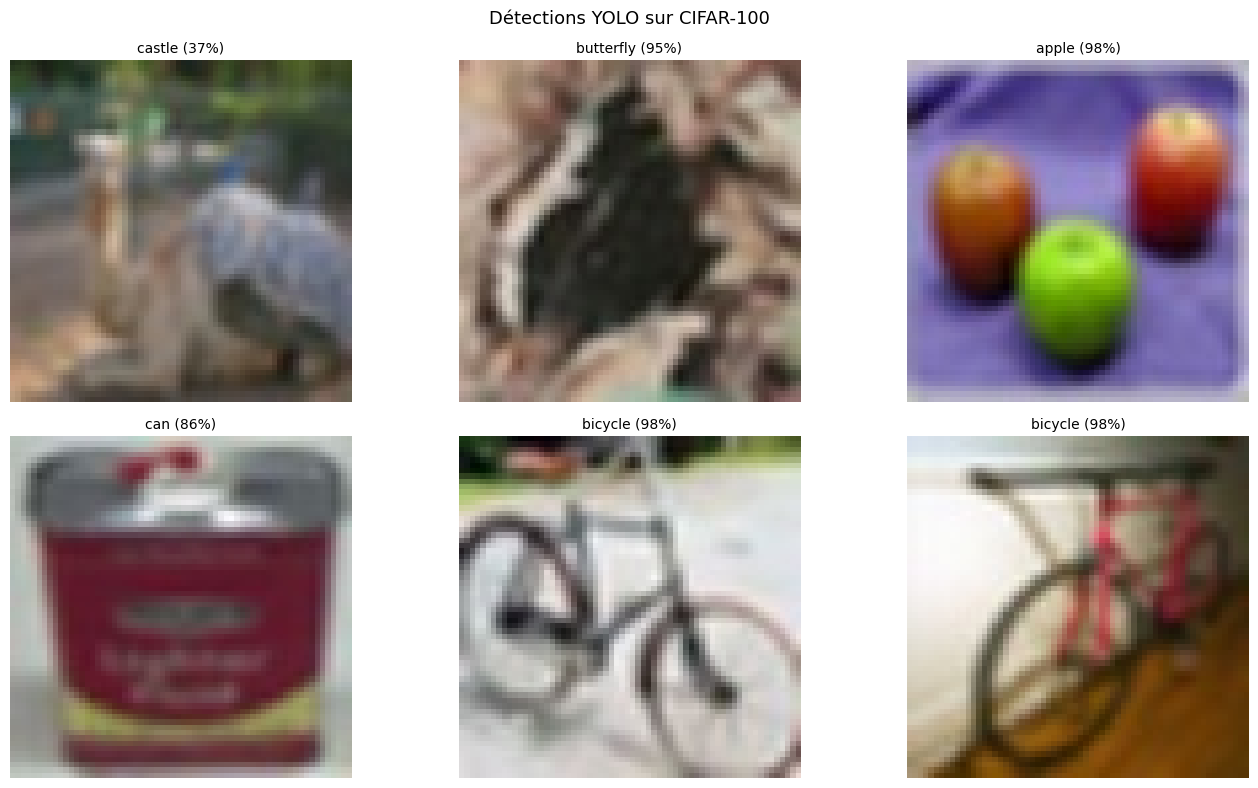

In [6]:
# ============================================
# 12. Test visuel sur quelques images
# ============================================
import matplotlib.pyplot as plt
import glob

test_images = glob.glob(f"{YOLO_ROOT}/images/val/*.jpg")[:6]
results_vis = best.predict(source=test_images, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, result in zip(axes.flat, results_vis):
    img = result.orig_img[:, :, ::-1]
    ax.imshow(img)
    for box in result.boxes:
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        ax.set_title(f"{result.names[cls]} ({conf*100:.0f}%)", fontsize=10)
    ax.axis('off')

plt.suptitle("Détections YOLO sur CIFAR-100", fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# ============================================
# EXPORT : YOLO → TFLite → Keras → TFJS
# ============================================
from ultralytics import YOLO
import tensorflow as tf

# 1. Charger le meilleur modèle entraîné
best = YOLO('/content/drive/MyDrive/yolo_results/cifar100_yolo/weights/best.pt')

# 2. Exporter en format TensorFlow SavedModel
best.export(format='saved_model', imgsz=64)
# → génère un dossier : cifar100_yolo/weights/best_saved_model/

# 3. Charger le SavedModel et le sauvegarder en .keras
saved_model_path = '/content/drive/MyDrive/yolo_results/cifar100_yolo/weights/best_saved_model'
tf_model = tf.saved_model.load(saved_model_path)

# Convertir en modèle Keras
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

# Sauvegarder le .tflite (léger, idéal pour le web)
with open('/content/drive/MyDrive/best_yolo.tflite', 'wb') as f:
    f.write(tflite_model)
print("✅ Modèle .tflite exporté")

# OU sauvegarder en .keras (Keras natif)
keras_model = tf.keras.models.load_model(saved_model_path)
keras_model.save('/content/drive/MyDrive/best_yolo.keras')
print("✅ Modèle .keras exporté")

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo_results/cifar100_yolo/weights/best.pt' with input shape (1, 3, 64, 64) BCHW and output shape(s) (1, 24, 84) (5.9 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 6.05s
Prepared 9 packages in 6.10s
Installed 9 packages in 340ms
 + ai-edge-litert==2.1.4
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + onnx==1.21.0
 + onnx-graphsurgeon==0.6.1
 + onnx2tf==1.28.8
 + onnxruntime-gpu

ValueError: File format not supported: filepath=/content/drive/MyDrive/yolo_results/cifar100_yolo/weights/best_saved_model. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(/content/drive/MyDrive/yolo_results/cifar100_yolo/weights/best_saved_model, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).